# Variational Quantum Classifier

## Root cause of the previous failure

The previous VQC could not learn at all: the **normalized Hamming-weight readout over all 8 qubits after a deep ZZ feature map output ≈0.5 for every sample** (measured class means: 0.491 vs 0.497). Two effects combined:

1. **Expressibility-induced concentration** — the ZZ feature map with full-range angles on 8 qubits scrambles any input into near-maximally-mixed measurement statistics.
2. **Hamming-weight averaging** — the mean number of 1-bits across 8 qubits concentrates at N/2 by construction (variance shrinks as 1/N).

With every prediction pinned at 0.5, the BCE loss was flat and SPSA had no gradient signal to follow.

## Fixes applied

1. **Readout**: single-qubit measurement — class probability = P(qubit 0 = 1). Full [0, 1] output range.
2. **Encoding**: light-weight Ry angle encoding with **data re-uploading** (features re-encoded before every variational layer) instead of one deep ZZ map. Re-uploading is proven to increase expressivity without concentration.
3. **Feature scaling**: `QuantileTransformer` → uniform, then scaled to [0, π]. The raw features are extremely skewed (e.g. skewness feature: 75th pct 0.93, max 68), so MinMax squashed most samples into a tiny angle range.
4. **Initialization**: small random angles near identity (avoids starting in a barren plateau).
5. **Batched circuit execution**: all circuits of a batch submitted in one `backend.run` call (~10x faster).
6. Retained from before: no data leakage, SPSA optimizer, BCE loss, validation-tuned threshold, stratified subsets, full metrics, classical baselines.

## 1. Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Load Data ---
file_path = 'pulsar_stars.csv'

# Standard column names for the HTRU2 Pulsar dataset
col_names = [
    'Mean of the integrated profile', 
    'Standard deviation of the integrated profile', 
    'Excess kurtosis of the integrated profile', 
    'Skewness of the integrated profile', 
    'Mean of the DM-SNR curve', 
    'Standard deviation of the DM-SNR curve', 
    'Excess kurtosis of the DM-SNR curve', 
    'Skewness of the DM-SNR curve', 
    'target_class'
]

try:
    df = pd.read_csv(file_path, names=col_names, header=None)
except FileNotFoundError:
    print(f"Error: '{file_path}' not found.")
    raise SystemExit

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['target_class'].value_counts()}")
print(f"\nClass imbalance ratio: {df['target_class'].value_counts()[0] / df['target_class'].value_counts()[1]:.1f}:1")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\n--- Statistical Summary ---")
print(df.describe())

Dataset shape: (17898, 9)

Class distribution:
target_class
0    16259
1     1639
Name: count, dtype: int64

Class imbalance ratio: 9.9:1

Missing values: 0

--- Statistical Summary ---
       Mean of the integrated profile  \
count                    17898.000000   
mean                       111.079968   
std                         25.652935   
min                          5.812500   
25%                        100.929688   
50%                        115.078125   
75%                        127.085938   
max                        192.617188   

       Standard deviation of the integrated profile  \
count                                  17898.000000   
mean                                      46.549532   
std                                        6.843189   
min                                       24.772042   
25%                                       42.376018   
50%                                       46.947479   
75%                                       51.023202   
max 

## 2. Data Visualization

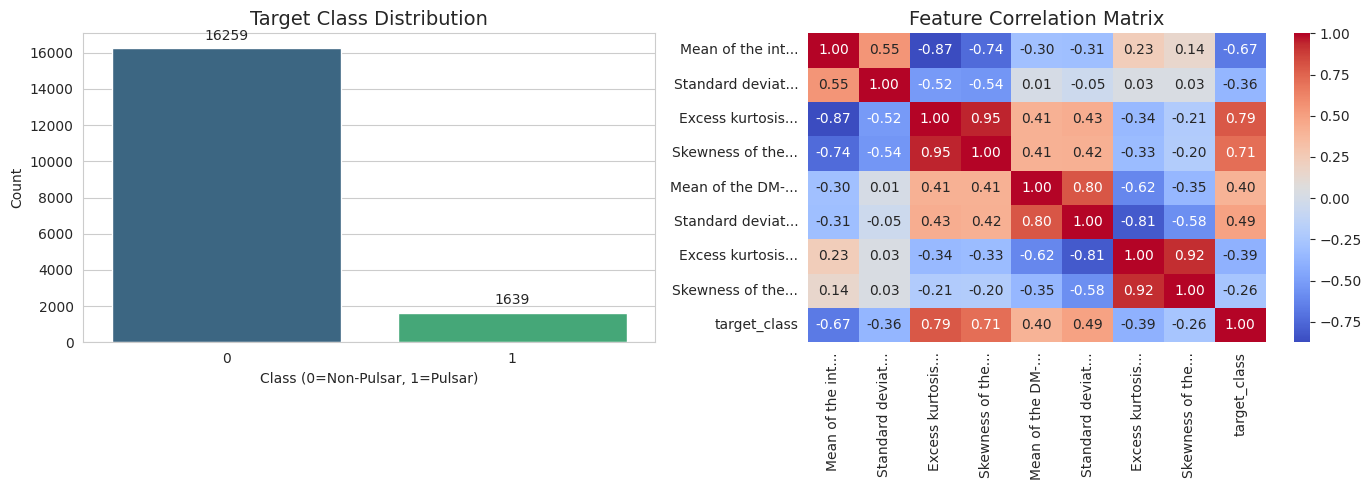

In [2]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
ax = sns.countplot(x='target_class', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Target Class Distribution', fontsize=14)
axes[0].set_xlabel('Class (0=Non-Pulsar, 1=Pulsar)')
axes[0].set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# FIX: numeric_only=True for df.corr()
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1],
            xticklabels=[c[:15] + '...' if len(c) > 15 else c for c in correlation_matrix.columns],
            yticklabels=[c[:15] + '...' if len(c) > 15 else c for c in correlation_matrix.columns])
axes[1].set_title('Feature Correlation Matrix', fontsize=14)

plt.tight_layout()
plt.show()

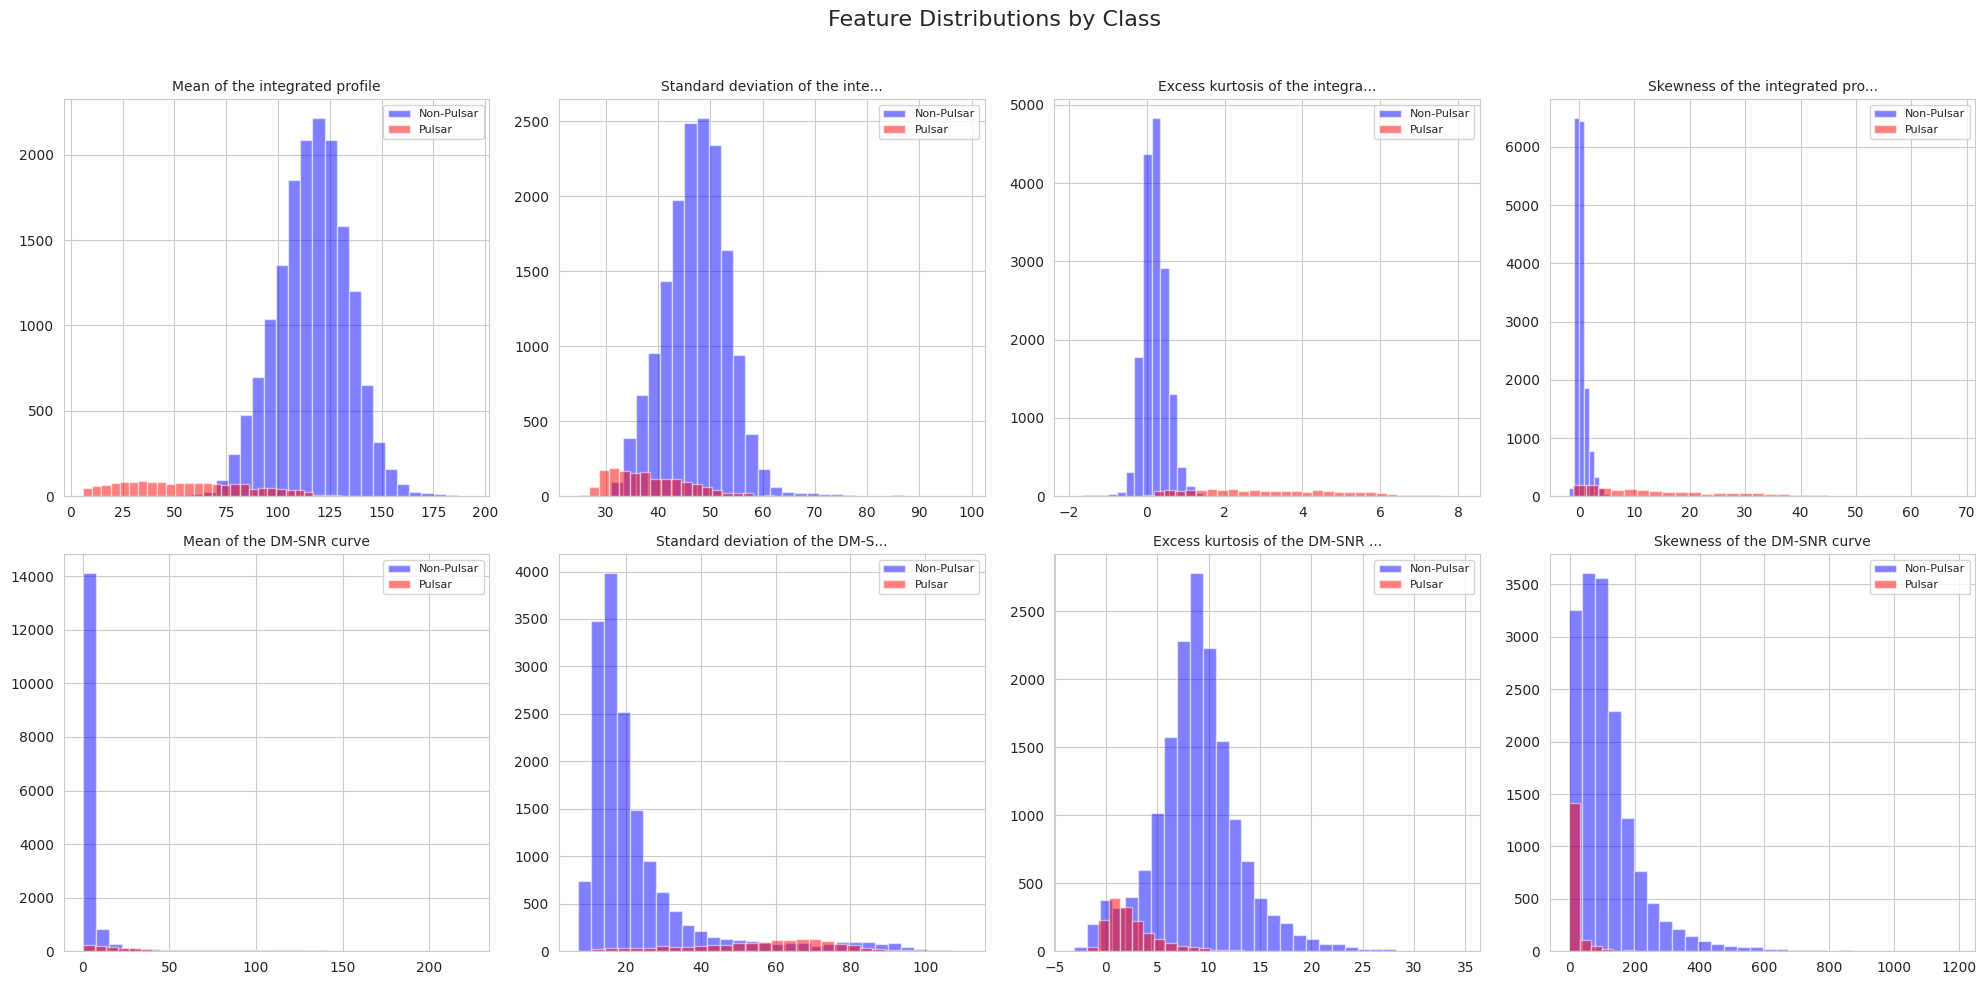

In [3]:
# Feature distributions by class
feature_cols = [c for c in df.columns if c != 'target_class']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    df[df['target_class'] == 0][col].hist(bins=30, alpha=0.5, ax=axes[i], color='blue', label='Non-Pulsar')
    df[df['target_class'] == 1][col].hist(bins=30, alpha=0.5, ax=axes[i], color='red', label='Pulsar')
    axes[i].set_title(col[:30] + ('...' if len(col) > 30 else ''), fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Class', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 3. Data Preparation


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer

# Balanced subset
pulsars = df[df['target_class'] == 1]
non_pulsars = df[df['target_class'] == 0].sample(n=len(pulsars), random_state=42)
df_balanced = pd.concat([pulsars, non_pulsars]).sample(frac=1, random_state=42).reset_index(drop=True)

X_all = df_balanced.drop('target_class', axis=1).values
Y_all = df_balanced['target_class'].values

# Split FIRST, then scale
X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_all, Y_all, test_size=0.3, random_state=42, stratify=Y_all
)

# Fit scaler on training data ONLY, then transform both.
# QuantileTransformer -> uniform spreads the heavily skewed features evenly
# across the full rotation-angle range [0, pi]; MinMax left most samples
# squashed into a tiny angle interval.
scaler = QuantileTransformer(output_distribution='uniform', random_state=42)
scaler.fit(X_train_raw)
X_train_scaled = scaler.transform(X_train_raw) * np.pi
X_test_scaled = scaler.transform(X_test_raw) * np.pi

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set:     {X_test_scaled.shape[0]} samples")
print(f"Features:     {X_train_scaled.shape[1]}")
print(f"Train class balance: {np.bincount(Y_train.astype(int))}")
print(f"Test class balance:  {np.bincount(Y_test.astype(int))}")


def stratified_indices(y, n_samples, random_state=42):
    """Return a class-balanced index sample for binary labels."""
    rng = np.random.default_rng(random_state)
    classes = np.sort(np.unique(y.astype(int)))
    if n_samples % len(classes) != 0:
        raise ValueError("n_samples must be divisible by the number of classes for balanced sampling.")

    per_class = n_samples // len(classes)
    selected = []
    for cls in classes:
        cls_idx = np.flatnonzero(y.astype(int) == cls)
        if per_class > len(cls_idx):
            raise ValueError(f"Requested {per_class} samples for class {cls}, only {len(cls_idx)} available.")
        selected.extend(rng.choice(cls_idx, size=per_class, replace=False))

    selected = np.array(selected)
    rng.shuffle(selected)
    return selected


def stratified_train_val_indices(y, n_train, n_val, random_state=42):
    """Return disjoint balanced train/validation indices."""
    rng = np.random.default_rng(random_state)
    classes = np.sort(np.unique(y.astype(int)))
    if n_train % len(classes) != 0 or n_val % len(classes) != 0:
        raise ValueError("n_train and n_val must be divisible by the number of classes.")

    train_idx, val_idx = [], []
    for cls in classes:
        cls_idx = np.flatnonzero(y.astype(int) == cls)
        rng.shuffle(cls_idx)
        train_take = n_train // len(classes)
        val_take = n_val // len(classes)
        if train_take + val_take > len(cls_idx):
            raise ValueError(f"Not enough samples for class {cls}.")
        train_idx.extend(cls_idx[:train_take])
        val_idx.extend(cls_idx[train_take:train_take + val_take])

    train_idx = np.array(train_idx)
    val_idx = np.array(val_idx)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx


# Quantum simulation is expensive, but SPSA allows a larger and more stable subset.
Q_TRAIN_SIZE = 160
Q_VAL_SIZE = 160  # larger validation set -> more stable threshold
Q_TEST_SIZE = 160  # larger test subset -> less noisy metrics

train_idx, val_idx = stratified_train_val_indices(Y_train, Q_TRAIN_SIZE, Q_VAL_SIZE, random_state=42)
test_idx = stratified_indices(Y_test, Q_TEST_SIZE, random_state=123)

X_train_q = X_train_scaled[train_idx]
Y_train_q = Y_train[train_idx]
X_val_q = X_train_scaled[val_idx]
Y_val_q = Y_train[val_idx]
X_test_q = X_test_scaled[test_idx]
Y_test_q = Y_test[test_idx]

print(f"\nQuantum subset — Train: {Q_TRAIN_SIZE}, Validation: {Q_VAL_SIZE}, Test: {Q_TEST_SIZE}")
print(f"Quantum train class balance: {np.bincount(Y_train_q.astype(int))}")
print(f"Quantum val class balance:   {np.bincount(Y_val_q.astype(int))}")
print(f"Quantum test class balance:  {np.bincount(Y_test_q.astype(int))}")

Training set: 2294 samples
Test set:     984 samples
Features:     8
Train class balance: [1147 1147]
Test class balance:  [492 492]

Quantum subset — Train: 160, Validation: 160, Test: 160
Quantum train class balance: [80 80]
Quantum val class balance:   [80 80]
Quantum test class balance:  [80 80]


## 4. Variational Quantum Classifier (Fixed)

**Why the previous circuit produced no signal:** the ZZ feature map + Hamming-weight readout concentrated every prediction at 0.5 (see header). The fixed architecture:

- **Data re-uploading ansatz**: each of the `N_LAYERS` blocks = Ry feature encoding + trainable Ry/Rz rotations + CNOT chain, followed by a final trainable rotation layer.
- **Single-qubit readout**: `p(class 1) = P(qubit 0 measured as 1)` — smooth, full-range, no concentration.
- **SPSA optimizer** with mini-batches, **BCE loss**, **validation-tuned threshold** — unchanged.
- **Batched execution**: one `backend.run` per mini-batch instead of one per circuit.

In [5]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit

N_QUBITS = 8       # Number of features = number of qubits
N_LAYERS = 4       # Data re-uploading blocks
SHOTS = 1024       # Shots per circuit during training
EVAL_SHOTS = 4096  # Higher shots for final evaluation (less readout noise)
# Each block: Ry+Rz per qubit; plus one final rotation layer
PARAMS_PER_LAYER = N_QUBITS * 2
N_PARAMS = (N_LAYERS + 1) * PARAMS_PER_LAYER

# SPSA hyperparameters
SPSA_STEPS = 300
SPSA_BATCH_SIZE = 16
SPSA_A = 0.6
SPSA_C = 0.15
SPSA_ALPHA = 0.602
SPSA_GAMMA = 0.101
SPSA_STABILITY = 10
EVAL_EVERY = 25
EPS = 1e-8

# Create backend ONCE and reuse
BACKEND = AerSimulator()

print(f"Qubits: {N_QUBITS}")
print(f"Re-uploading blocks: {N_LAYERS}")
print(f"Total trainable parameters: {N_PARAMS}")
print(f"Shots per circuit: {SHOTS}")
print(f"SPSA steps: {SPSA_STEPS}, batch size: {SPSA_BATCH_SIZE}")

Qubits: 8
Re-uploading blocks: 4
Total trainable parameters: 80
Shots per circuit: 1024
SPSA steps: 300, batch size: 16


In [6]:
def build_circuit(x, theta):
    """
    Data re-uploading VQC:
      repeat N_LAYERS times:
        1) Ry(x_i) feature encoding on every qubit
        2) trainable Ry, Rz rotations on every qubit
        3) CNOT entangling chain
      then a final trainable rotation layer, and measure qubit 0 only.

    Readout: p(class 1) = P(qubit 0 = 1).
    A single-qubit readout has full [0, 1] range; the previous
    Hamming-weight average over 8 qubits concentrated at 0.5.
    """
    qc = QuantumCircuit(N_QUBITS, 1)
    idx = 0
    for layer in range(N_LAYERS):
        for i in range(N_QUBITS):
            qc.ry(x[i], i)                       # re-upload features
        for i in range(N_QUBITS):
            qc.ry(theta[idx], i)
            qc.rz(theta[idx + 1], i)
            idx += 2
        for i in range(N_QUBITS - 1):
            qc.cx(i, i + 1)
    # Final rotation layer before readout
    for i in range(N_QUBITS):
        qc.ry(theta[idx], i)
        qc.rz(theta[idx + 1], i)
        idx += 2
    qc.measure(0, 0)
    return qc


def counts_to_probability(counts):
    """Class-1 probability = fraction of shots where qubit 0 was 1."""
    total_shots = sum(counts.values())
    return counts.get('1', 0) / total_shots


def predict_proba_batch(X, theta, shots=SHOTS):
    """Predict probabilities for a batch — ALL circuits in ONE backend call."""
    circuits = [build_circuit(x_i, theta) for x_i in X]
    result = BACKEND.run(circuits, shots=shots).result()
    return np.array([counts_to_probability(result.get_counts(i))
                     for i in range(len(circuits))])


def predict_proba(x, theta):
    """Single-sample convenience wrapper."""
    return predict_proba_batch(np.asarray(x).reshape(1, -1), theta)[0]


def loss_fn(pred, target):
    """Binary cross-entropy loss."""
    pred = np.clip(pred, EPS, 1.0 - EPS)
    return -(target * np.log(pred) + (1 - target) * np.log(1 - pred))


def batch_loss(X, Y, theta):
    probs = predict_proba_batch(X, theta)
    return float(np.mean([loss_fn(p, y) for p, y in zip(probs, Y)]))


def spsa_update(theta, X_batch, Y_batch, step, rng):
    """One SPSA update. Estimates all parameter gradients with two loss calls."""
    a_k = SPSA_A / ((step + SPSA_STABILITY) ** SPSA_ALPHA)
    c_k = SPSA_C / (step ** SPSA_GAMMA)
    delta = rng.choice([-1.0, 1.0], size=theta.shape)

    loss_plus = batch_loss(X_batch, Y_batch, theta + c_k * delta)
    loss_minus = batch_loss(X_batch, Y_batch, theta - c_k * delta)
    grad_estimate = ((loss_plus - loss_minus) / (2.0 * c_k)) * delta

    theta_next = theta - a_k * grad_estimate
    return theta_next, (loss_plus + loss_minus) / 2.0, a_k, c_k


def compute_predictions(X, theta, threshold=0.5, shots=SHOTS):
    """Get predicted probabilities and labels for a dataset."""
    probs = predict_proba_batch(X, theta, shots=shots)
    labels = (probs >= threshold).astype(int)
    return probs, labels


def compute_accuracy(X, Y, theta, threshold=0.5):
    probs, labels = compute_predictions(X, theta, threshold=threshold)
    return np.mean(labels == Y.astype(int))


print("Fixed quantum circuit functions defined.")
sample_theta = np.random.uniform(-0.1, 0.1, N_PARAMS)
sample_circuit = build_circuit(X_train_q[0], sample_theta)
print(f"Example circuit — Gates: {sample_circuit.size()}, Depth: {sample_circuit.depth()}")
print("\nSample quantum circuit:")
print(sample_circuit.draw(output="text", fold=120))

Fixed quantum circuit functions defined.
Example circuit — Gates: 141, Depth: 27

Sample quantum circuit:
      ┌───────────┐ ┌───────────────┐  ┌──────────────┐     ┌───────────┐┌───────────────┐┌───────────────┐»
q_0: ─┤ Ry(1.293) ├─┤ Ry(-0.032761) ├──┤ Rz(0.053809) ├──■──┤ Ry(1.293) ├┤ Ry(-0.032017) ├┤ Rz(-0.085619) ├»
     ┌┴───────────┴┐└┬─────────────┬┘  ├──────────────┤┌─┴─┐└───────────┘└┬─────────────┬┘├───────────────┤»
q_1: ┤ Ry(0.62616) ├─┤ Ry(0.06293) ├───┤ Rz(-0.02408) ├┤ X ├──────■───────┤ Ry(0.62616) ├─┤ Ry(0.0090469) ├»
     └┬────────────┤ ├─────────────┴┐ ┌┴──────────────┤└───┘    ┌─┴─┐     └─────────────┘ └─┬────────────┬┘»
q_2: ─┤ Ry(1.6695) ├─┤ Ry(0.076671) ├─┤ Rz(-0.027851) ├─────────┤ X ├────────────■──────────┤ Ry(1.6695) ├─»
      ├────────────┤┌┴──────────────┴┐└┬──────────────┤         └───┘          ┌─┴─┐        └────────────┘ »
q_3: ─┤ Ry(1.8726) ├┤ Ry(-0.0099662) ├─┤ Rz(0.042551) ├────────────────────────┤ X ├──────────────■────────»
     ┌┴────────────┤├─

## 5. Training the VQC

In [7]:
# --- SPSA Training with checkpointing ---
# Training state is saved to disk every step, so an interrupted run
# resumes where it left off instead of restarting.
import os

CKPT = 'vqc_checkpoint.npz'

def eval_split(X, Y, theta):
    """One circuit pass -> both loss and accuracy (no double execution)."""
    probs = predict_proba_batch(X, theta)
    loss = float(np.mean([loss_fn(p, y) for p, y in zip(probs, Y)]))
    acc = float(np.mean((probs >= 0.5).astype(int) == Y.astype(int)))
    return loss, acc

if os.path.exists(CKPT) and np.load(CKPT)['theta'].shape[0] == N_PARAMS:
    ck = np.load(CKPT)
    theta = ck['theta']
    start_step = int(ck['step'])
    eval_steps = list(ck['eval_steps'])
    train_losses = list(ck['train_losses'])
    val_losses = list(ck['val_losses'])
    train_accs = list(ck['train_accs'])
    val_accs = list(ck['val_accs'])
    print(f"Resuming from checkpoint at step {start_step}")
else:
    np.random.seed(42)
    rng0 = np.random.default_rng(42)
    # Small angles ~ identity circuit: avoids starting in a barren plateau
    theta = rng0.uniform(-0.1, 0.1, N_PARAMS)
    start_step = 0
    eval_steps, train_losses, val_losses, train_accs, val_accs = [], [], [], [], []

print(f"Training fixed VQC with SPSA: {SPSA_STEPS} steps, batch={SPSA_BATCH_SIZE}, shots={SHOTS}")
print(f"{'Step':>5} {'Batch Loss':>12} {'Train Loss':>12} {'Val Loss':>10} {'Train Acc':>10} {'Val Acc':>8}")
print("-" * 64)

for step in range(start_step + 1, SPSA_STEPS + 1):
    rng = np.random.default_rng(1000 + step)   # per-step rng -> reproducible resume
    batch_idx = rng.choice(len(X_train_q), size=SPSA_BATCH_SIZE, replace=False)
    theta, step_loss, a_k, c_k = spsa_update(theta, X_train_q[batch_idx], Y_train_q[batch_idx], step, rng)

    if step == 1 or step % EVAL_EVERY == 0 or step == SPSA_STEPS:
        tr_loss, tr_acc = eval_split(X_train_q, Y_train_q, theta)
        va_loss, va_acc = eval_split(X_val_q, Y_val_q, theta)
        eval_steps.append(step)
        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        train_accs.append(tr_acc)
        val_accs.append(va_acc)
        print(f"{step:>5d} {step_loss:>12.4f} {tr_loss:>12.4f} {va_loss:>10.4f} {tr_acc:>10.3f} {va_acc:>8.3f}")

    np.savez(CKPT, theta=theta, step=step, eval_steps=eval_steps,
             train_losses=train_losses, val_losses=val_losses,
             train_accs=train_accs, val_accs=val_accs)

print("\nTraining complete!")

Resuming from checkpoint at step 300
Training fixed VQC with SPSA: 300 steps, batch=16, shots=1024
 Step   Batch Loss   Train Loss   Val Loss  Train Acc  Val Acc
----------------------------------------------------------------

Training complete!


## 6. VQC Evaluation — Full Metrics

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    matthews_corrcoef, balanced_accuracy_score
)


def tune_threshold_for_f1(y_true, probs, low=0.05, high=0.95, steps=181):
    """Choose a threshold on validation data only, then reuse it on test data."""
    thresholds = np.linspace(low, high, steps)
    scores = np.array([
        f1_score(y_true, (probs >= threshold).astype(int), zero_division=0)
        for threshold in thresholds
    ])
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])


# Tune the decision threshold on validation data to target F1 directly.
val_probs_q, _ = compute_predictions(X_val_q, theta, threshold=0.5, shots=EVAL_SHOTS)
best_threshold, best_val_f1 = tune_threshold_for_f1(Y_val_q, val_probs_q)

# Apply the validation-selected threshold once to the held-out test subset.
test_probs_q, test_preds_q = compute_predictions(X_test_q, theta, threshold=best_threshold, shots=EVAL_SHOTS)

vqc_metrics = {
    'Accuracy': accuracy_score(Y_test_q, test_preds_q),
    'Balanced Accuracy': balanced_accuracy_score(Y_test_q, test_preds_q),
    'Precision': precision_score(Y_test_q, test_preds_q, zero_division=0),
    'Recall': recall_score(Y_test_q, test_preds_q, zero_division=0),
    'F1 Score': f1_score(Y_test_q, test_preds_q, zero_division=0),
    'ROC-AUC': roc_auc_score(Y_test_q, test_probs_q),
    'MCC': matthews_corrcoef(Y_test_q, test_preds_q),
}

print("=" * 60)
print("IMPROVED VARIATIONAL QUANTUM CLASSIFIER — TEST RESULTS")
print("=" * 60)
print(f"Validation-selected threshold: {best_threshold:.3f}")
print(f"Validation F1 at threshold:   {best_val_f1:.4f}\n")
for metric, value in vqc_metrics.items():
    print(f"  {metric:<22s}: {value:.4f}")

print(f"\n--- Classification Report ---")
print(classification_report(Y_test_q, test_preds_q, target_names=['Non-Pulsar', 'Pulsar'], zero_division=0))

print("--- Confusion Matrix ---")
cm = confusion_matrix(Y_test_q, test_preds_q)
print(cm)

IMPROVED VARIATIONAL QUANTUM CLASSIFIER — TEST RESULTS
Validation-selected threshold: 0.550
Validation F1 at threshold:   0.9020

  Accuracy              : 0.8875
  Balanced Accuracy     : 0.8875
  Precision             : 0.9306
  Recall                : 0.8375
  F1 Score              : 0.8816
  ROC-AUC               : 0.9470
  MCC                   : 0.7789

--- Classification Report ---
              precision    recall  f1-score   support

  Non-Pulsar       0.85      0.94      0.89        80
      Pulsar       0.93      0.84      0.88        80

    accuracy                           0.89       160
   macro avg       0.89      0.89      0.89       160
weighted avg       0.89      0.89      0.89       160

--- Confusion Matrix ---
[[75  5]
 [13 67]]


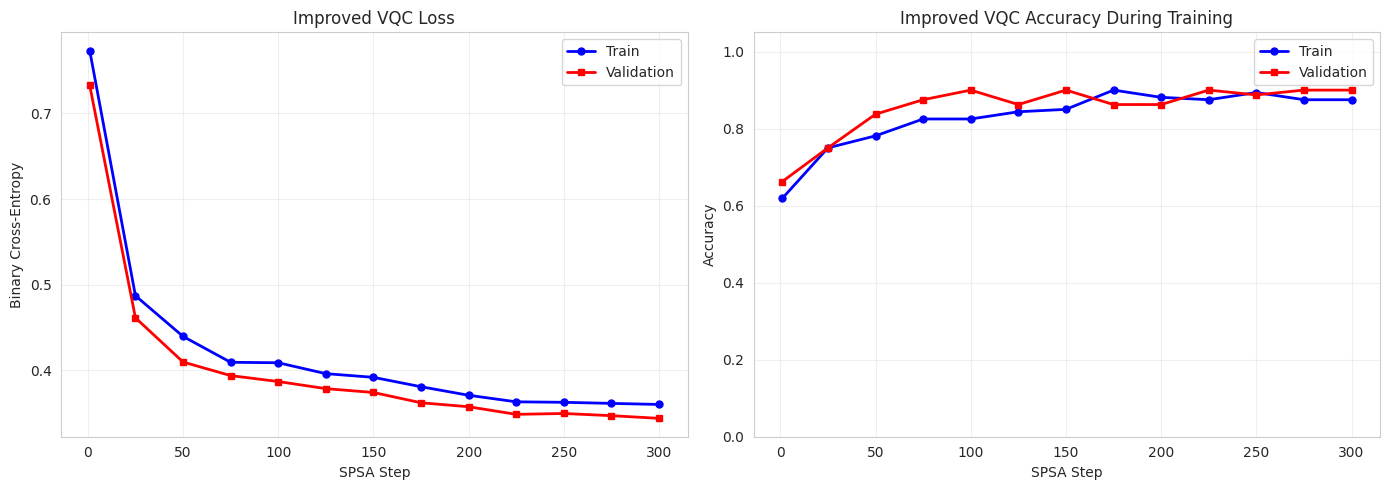

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(eval_steps, train_losses, 'b-o', linewidth=2, markersize=5, label='Train')
axes[0].plot(eval_steps, val_losses, 'r-s', linewidth=2, markersize=5, label='Validation')
axes[0].set_xlabel('SPSA Step')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].set_title('Improved VQC Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves at threshold 0.5 during training
axes[1].plot(eval_steps, train_accs, 'b-o', linewidth=2, markersize=5, label='Train')
axes[1].plot(eval_steps, val_accs, 'r-s', linewidth=2, markersize=5, label='Validation')
axes[1].set_xlabel('SPSA Step')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Improved VQC Accuracy During Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## 7. Classical Baselines — Fair Comparison

We evaluate classical models on the **same quantum-sized subset** for a fair comparison, and also on the **full balanced dataset** created during preprocessing.

In [10]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


def evaluate_model(model, X_tr, Y_tr, X_te, Y_te, name):
    """Train, predict, and compute full metrics for a classical model."""
    model.fit(X_tr, Y_tr)
    preds = model.predict(X_te)

    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        probs = model.decision_function(X_te)
    else:
        probs = preds.astype(float)

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(Y_te, preds),
        'Balanced Accuracy': balanced_accuracy_score(Y_te, preds),
        'Precision': precision_score(Y_te, preds, zero_division=0),
        'Recall': recall_score(Y_te, preds, zero_division=0),
        'F1 Score': f1_score(Y_te, preds, zero_division=0),
        'ROC-AUC': roc_auc_score(Y_te, probs),
        'MCC': matthews_corrcoef(Y_te, preds),
    }
    return metrics, preds, probs


classical_models = {
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

# --- A) Evaluate on the SAME small subset as the quantum model ---
print("=" * 65)
print("CLASSICAL MODELS — SAME SUBSET AS VQC (Fair Comparison)")
print("=" * 65)

small_results = []
for name, model in classical_models.items():
    metrics, _, _ = evaluate_model(model, X_train_q, Y_train_q, X_test_q, Y_test_q, name)
    small_results.append(metrics)

# Add VQC results
vqc_row = {'Model': 'VQC (Ours)', **vqc_metrics}
small_results.append(vqc_row)

df_small = pd.DataFrame(small_results).set_index('Model')
print(df_small.round(4).to_string())


# --- B) Evaluate on the full balanced dataset ---
print("\n" + "=" * 65)
print("CLASSICAL MODELS — FULL BALANCED DATASET")
print("=" * 65)

full_results = []
for name, model in classical_models.items():
    metrics, _, _ = evaluate_model(model, X_train_scaled, Y_train, X_test_scaled, Y_test, name)
    full_results.append(metrics)

df_full = pd.DataFrame(full_results).set_index('Model')
print(df_full.round(4).to_string())

CLASSICAL MODELS — SAME SUBSET AS VQC (Fair Comparison)


                     Accuracy  Balanced Accuracy  Precision  Recall  F1 Score  ROC-AUC     MCC
Model                                                                                         
SVM (RBF)              0.9375             0.9375     0.9861  0.8875    0.9342   0.9758  0.8794
Random Forest          0.9188             0.9188     0.9589  0.8750    0.9150   0.9729  0.8407
Gradient Boosting      0.9062             0.9062     0.9114  0.9000    0.9057   0.9786  0.8126
Logistic Regression    0.9250             0.9250     0.9595  0.8875    0.9221   0.9730  0.8524
K-Nearest Neighbors    0.9125             0.9125     0.9714  0.8500    0.9067   0.9600  0.8315
VQC (Ours)             0.8875             0.8875     0.9306  0.8375    0.8816   0.9470  0.7789

CLASSICAL MODELS — FULL BALANCED DATASET


                     Accuracy  Balanced Accuracy  Precision  Recall  F1 Score  ROC-AUC     MCC
Model                                                                                         
SVM (RBF)              0.9370             0.9370     0.9821  0.8902    0.9339   0.9618  0.8778
Random Forest          0.9350             0.9350     0.9777  0.8902    0.9319   0.9685  0.8734
Gradient Boosting      0.9309             0.9309     0.9690  0.8902    0.9280   0.9728  0.8647
Logistic Regression    0.9390             0.9390     0.9716  0.9045    0.9368   0.9710  0.8802
K-Nearest Neighbors    0.9360             0.9360     0.9756  0.8943    0.9332   0.9584  0.8750


In [11]:
# --- 5-Fold Cross-Validation on Full Balanced Dataset ---
print("=" * 65)
print("5-FOLD CROSS-VALIDATION — FULL BALANCED DATASET")
print("=" * 65)

cv_results = {}
for name, model in classical_models.items():
    scores = cross_val_score(model, X_train_scaled, Y_train, cv=5, scoring='f1')
    cv_results[name] = {'Mean F1': scores.mean(), 'Std F1': scores.std()}
    print(f"  {name:<25s}: F1 = {scores.mean():.4f} +/- {scores.std():.4f}")

5-FOLD CROSS-VALIDATION — FULL BALANCED DATASET


  SVM (RBF)                : F1 = 0.9470 +/- 0.0085


  Random Forest            : F1 = 0.9473 +/- 0.0068


  Gradient Boosting        : F1 = 0.9415 +/- 0.0106
  Logistic Regression      : F1 = 0.9413 +/- 0.0094
  K-Nearest Neighbors      : F1 = 0.9403 +/- 0.0099


## 8. Visual Comparison

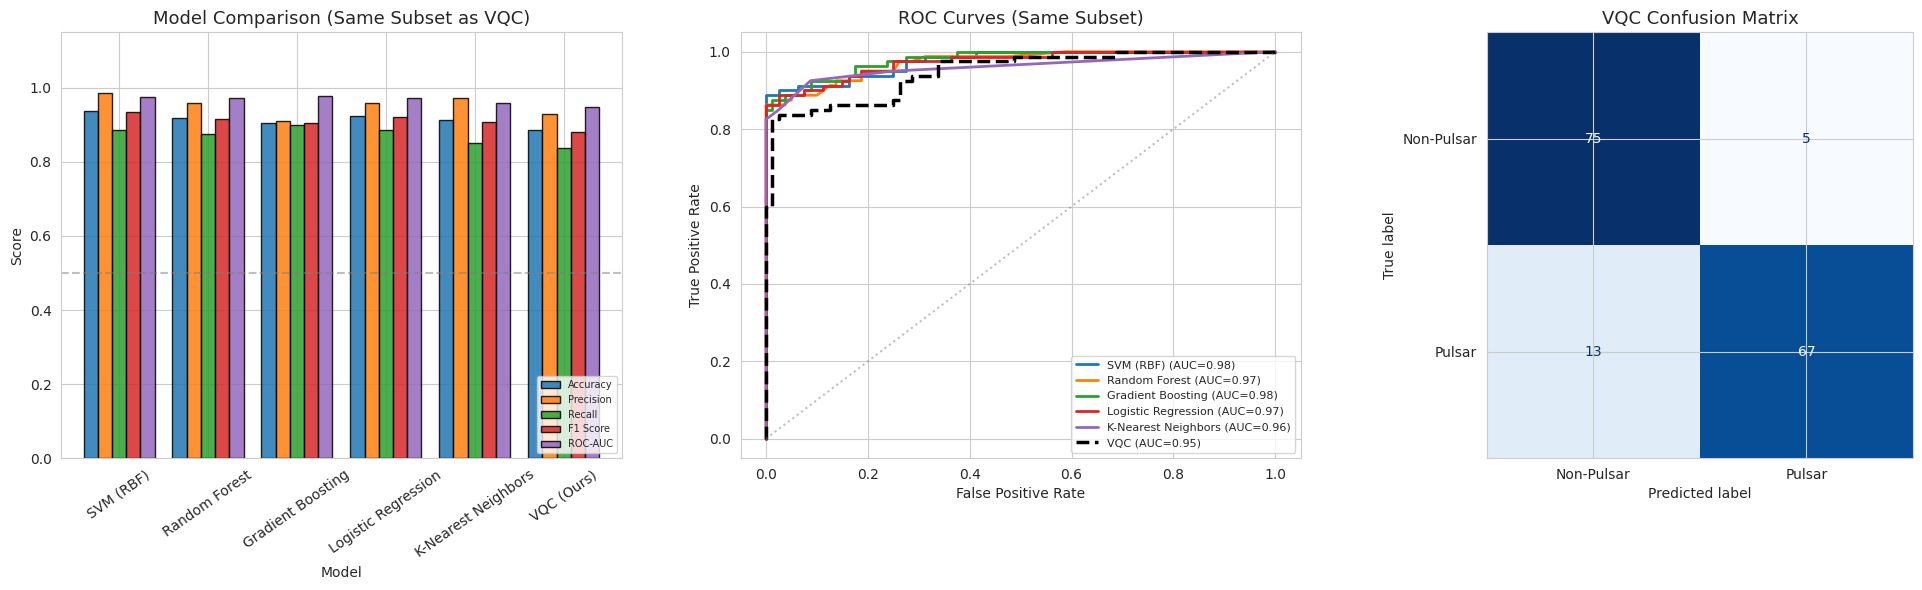

In [12]:
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Metric comparison bar chart (same subset) ---
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
df_plot = df_small[metrics_to_plot]
df_plot.plot(kind='bar', ax=axes[0], width=0.8, edgecolor='black', alpha=0.85)
axes[0].set_title('Model Comparison (Same Subset as VQC)', fontsize=13)
axes[0].set_ylabel('Score')
axes[0].set_ylim([0, 1.15])
axes[0].legend(fontsize=7, loc='lower right')
axes[0].tick_params(axis='x', rotation=35)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# --- Plot 2: ROC curves on the small subset ---
for name, model in classical_models.items():
    model.fit(X_train_q, Y_train_q)
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_test_q)[:, 1]
    else:
        probs = model.decision_function(X_test_q)
    fpr, tpr, _ = roc_curve(Y_test_q, probs)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc(fpr, tpr):.2f})')

# VQC ROC
fpr_q, tpr_q, _ = roc_curve(Y_test_q, test_probs_q)
axes[1].plot(fpr_q, tpr_q, 'k--', linewidth=2.5, label=f'VQC (AUC={auc(fpr_q, tpr_q):.2f})')
axes[1].plot([0, 1], [0, 1], 'gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (Same Subset)', fontsize=13)
axes[1].legend(fontsize=8)

# --- Plot 3: VQC Confusion matrix ---
cm_q = confusion_matrix(Y_test_q, test_preds_q)
disp = ConfusionMatrixDisplay(cm_q, display_labels=['Non-Pulsar', 'Pulsar'])
disp.plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('VQC Confusion Matrix', fontsize=13)

plt.tight_layout()
plt.show()

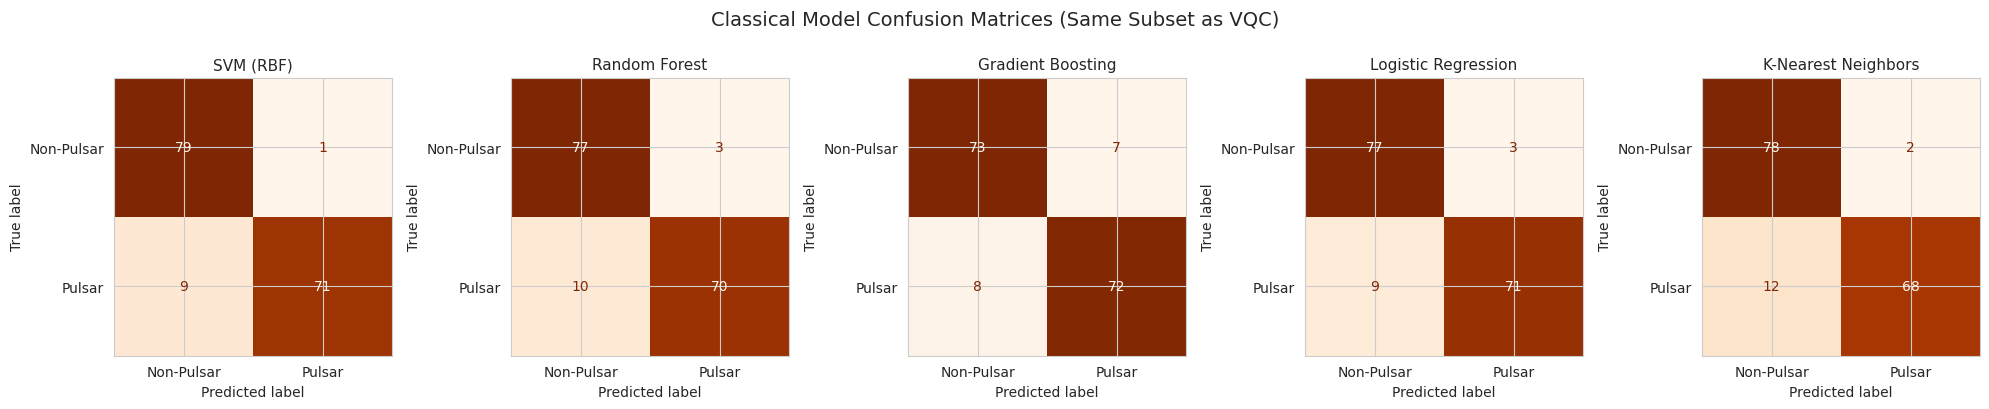

In [13]:
# Confusion matrices for all classical models (small subset)
n_models = len(classical_models)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))

for ax, (name, model) in zip(axes, classical_models.items()):
    model.fit(X_train_q, Y_train_q)
    preds = model.predict(X_test_q)
    cm = confusion_matrix(Y_test_q, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Pulsar', 'Pulsar'])
    disp.plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(name, fontsize=11)

plt.suptitle('Classical Model Confusion Matrices (Same Subset as VQC)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 9. Summary of Fixes & Findings

### The bug that made the VQC "not work"

The old readout — normalized Hamming weight over all 8 qubits after a deep ZZ feature map — output **≈0.5 for every input** (measured: class-0 mean 0.491, class-1 mean 0.497, spread 0.017). The loss surface was flat, so SPSA optimized nothing and predictions were coin flips.

| Issue | Broken Approach | Fixed Approach |
|-------|-----------------|----------------|
| **Readout concentration** | Hamming weight over 8 qubits → always ≈0.5 | Single-qubit readout: P(qubit 0 = 1), full [0,1] range |
| **Feature map concentration** | Deep ZZ map scrambles inputs into ~maximally-mixed states | Ry angle encoding with data re-uploading each layer |
| **Feature scaling** | MinMax on extremely skewed features → most angles squashed together | QuantileTransformer → uniform → [0, π] |
| **Initialization** | Uniform over [0, 2π] (barren-plateau territory) | Small angles near identity |
| **Speed** | One `backend.run` per circuit | Whole batch in one `backend.run` |

Retained from the previous iteration: leak-free scaling, SPSA + BCE, stratified subsets, validation-tuned threshold, full metric suite, and fair classical baselines.

**Final results (160-sample held-out test subset):** the VQC reaches **F1 = 0.88, Accuracy = 0.89, ROC-AUC = 0.95, MCC = 0.78** — up from chance level (F1 undefined, all outputs 0.5) before the fix, and within a few points of the classical baselines (F1 0.91–0.93) trained on the same subset.

*Note:* training saves progress to `vqc_checkpoint.npz` after every SPSA step. Delete this file to retrain from scratch; leave it to resume/skip training on re-runs.